In [1]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import warnings
import itertools
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit # Menggunakan GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

In [2]:
# =====================================================
# 2. LOAD DATA
# =====================================================

historical = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/wind farm historical data.csv")
nwp = pd.read_csv("/content/drive/MyDrive/Skripsi/Dataset/Wind Power/NWP.csv")

historical.columns = historical.columns.str.strip()
nwp.columns = nwp.columns.str.strip()

historical['Date'] = pd.to_datetime(historical['Date'], dayfirst=True)
nwp['time'] = pd.to_datetime(nwp['time'])

historical = historical.rename(columns={
    'Date':'timestamp',
    'Speed':'wind_speed',
    'Direction':'wind_direction',
    'Energy':'power'
})

nwp = nwp.rename(columns={
    'time':'timestamp',
    'mod':'wind_speed_nwp',
    'dir':'wind_dir_nwp',
    'temp':'temperature_nwp',
    'rh':'humidity_nwp',
    'mslp':'pressure_nwp'
})

data = pd.merge(historical, nwp, on='timestamp', how='inner')
data = data.sort_values('timestamp').reset_index(drop=True)
data = data.ffill().dropna()

print("Merged shape:", data.shape)

Merged shape: (8784, 9)


In [3]:
# =====================================================
# 3. FEATURE ENGINEERING
# =====================================================

data_fe = data.copy()

# Time features
data_fe['hour'] = data_fe['timestamp'].dt.hour
data_fe['month'] = data_fe['timestamp'].dt.month
data_fe['year'] = data_fe['timestamp'].dt.year

data_fe['hour_sin'] = np.sin(2*np.pi*data_fe['hour']/24)
data_fe['hour_cos'] = np.cos(2*np.pi*data_fe['hour']/24)

# Lag features
for lag in [1,2,3,6,12,24]:
    data_fe[f'power_lag_{lag}'] = data_fe['power'].shift(lag)

# Rolling features
data_fe['rolling_mean_6'] = data_fe['power'].rolling(6).mean()
data_fe['rolling_std_6'] = data_fe['power'].rolling(6).std()

# ----------------------------
# Physics-informed features
# ----------------------------

data_fe['temp_kelvin'] = data_fe['temperature_nwp'] + 273.15
data_fe['pressure_pascal'] = data_fe['pressure_nwp'] * 100

R_specific = 287.058
data_fe['air_density'] = data_fe['pressure_pascal'] / (R_specific * data_fe['temp_kelvin'])

data_fe['physics_theoretical_power'] = 0.5 * data_fe['air_density'] * (data_fe['wind_speed_nwp']**3)

data_fe = data_fe.dropna().reset_index(drop=True)

print("After feature engineering:", data_fe.shape)

After feature engineering: (8760, 26)


In [4]:
# =====================================================
# 4. XGBOOST MODEL (DEFAULT VS TUNED)
# =====================================================

test_months = [10, 11, 12]
results_xgb = []

features = data_fe.drop(['timestamp', 'power', 'year', 'month'], axis=1).columns

# Parameter Grid yang dirancang khusus untuk GridSearchCV agar komputasi masuk akal
param_grid_xgb = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

for month in test_months:
    train_data = data_fe[data_fe['month'] < month]
    test_data = data_fe[data_fe['month'] == month]

    if len(train_data) == 0 or len(test_data) == 0:
        continue

    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train_data[features])
    X_test = scaler.transform(test_data[features])

    y_train = train_data['power']
    y_test = test_data['power']

    # --- 4A. XGBOOST DEFAULT ---
    model_default = XGBRegressor(objective='reg:squarederror', random_state=42)
    model_default.fit(X_train, y_train)
    preds_default = model_default.predict(X_test)

    results_xgb.append({
        'Month': month,
        'Model': 'XGBoost (Default)',
        'RMSE': np.sqrt(mean_squared_error(y_test, preds_default)),
        'MAE': mean_absolute_error(y_test, preds_default),
        'R2': r2_score(y_test, preds_default)
    })

    # --- 4B. XGBOOST TUNED (GRID SEARCH CV) ---
    tscv = TimeSeriesSplit(n_splits=3)
    model_tune = XGBRegressor(objective='reg:squarederror', random_state=42)

    # Menggunakan GridSearchCV menggantikan RandomizedSearchCV
    grid_search = GridSearchCV(
        estimator=model_tune,
        param_grid=param_grid_xgb,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    best_xgb = grid_search.best_estimator_
    preds_tuned = best_xgb.predict(X_test)

    results_xgb.append({
        'Month': month,
        'Model': 'XGBoost (Tuned)',
        'RMSE': np.sqrt(mean_squared_error(y_test, preds_tuned)),
        'MAE': mean_absolute_error(y_test, preds_tuned),
        'R2': r2_score(y_test, preds_tuned)
    })

    print(f"XGBoost Bulan {month} - Best Params: {grid_search.best_params_}")

xgb_df = pd.DataFrame(results_xgb)
print("\n=== XGBoost Summary ===")
print(xgb_df)

XGBoost Bulan 10 - Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.8}
XGBoost Bulan 11 - Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.8}
XGBoost Bulan 12 - Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.8}

=== XGBoost Summary ===
   Month              Model        RMSE         MAE        R2
0     10  XGBoost (Default)   94.883854   61.918646  0.929433
1     10    XGBoost (Tuned)   93.401528   62.609570  0.931621
2     11  XGBoost (Default)  160.505179  103.976445  0.932585
3     11    XGBoost (Tuned)  141.996941   95.683597  0.947236
4     12  XGBoost (Default)  136.671949   84.462008  0.885887
5     12    XGBoost (Tuned)  132.864350   86.282383  0.892157


In [5]:
# =====================================================
# 5. ARIMA BASELINE (DEFAULT VS TUNED)
# =====================================================

results_arima = []

# Ruang lingkup pencarian Grid Search manual untuk parameter (p, d, q) ARIMA
# Ini dieksekusi menggunakan logika kombinatorik (itertools.product) yang merepresentasikan Grid Search murni
p_values = [0, 1, 2, 3]
d_values = [0, 1]
q_values = [0, 1, 2, 3]

for month in test_months:
    train_data = data_fe[data_fe['month'] < month]
    test_data = data_fe[data_fe['month'] == month]

    if len(train_data) == 0 or len(test_data) == 0:
        continue

    # Menggunakan .values untuk menghilangkan ValueWarning dari Statsmodels
    y_train = train_data['power'].values
    y_test = test_data['power'].values

    # --- 5A. ARIMA DEFAULT ---
    model_default = ARIMA(y_train, order=(2, 1, 2))
    model_fit_default = model_default.fit()
    preds_default = model_fit_default.forecast(steps=len(y_test))

    results_arima.append({
        'Month': month,
        'Model': 'ARIMA (Default)',
        'RMSE': np.sqrt(mean_squared_error(y_test, preds_default)),
        'MAE': mean_absolute_error(y_test, preds_default),
        'R2': r2_score(y_test, preds_default)
    })

    # --- 5B. ARIMA TUNED (GRID SEARCH BERDASARKAN AIC) ---
    best_aic = float("inf")
    best_order = None

    # Pencarian parameter terbaik secara menyeluruh (Grid Search)
    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            model = ARIMA(y_train, order=(p, d, q))
            res = model.fit()
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, d, q)
        except:
            continue

    print(f"ARIMA Bulan {month} - Best Order (p,d,q): {best_order} dengan AIC: {best_aic:.2f}")

    # Prediksi dengan model terbaik hasil Grid Search
    model_tuned = ARIMA(y_train, order=best_order)
    model_fit_tuned = model_tuned.fit()
    preds_tuned = model_fit_tuned.forecast(steps=len(y_test))

    results_arima.append({
        'Month': month,
        'Model': 'ARIMA (Tuned)',
        'RMSE': np.sqrt(mean_squared_error(y_test, preds_tuned)),
        'MAE': mean_absolute_error(y_test, preds_tuned),
        'R2': r2_score(y_test, preds_tuned)
    })

arima_df = pd.DataFrame(results_arima)
print("\n=== ARIMA Summary ===")
print(arima_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA Bulan 10 - Best Order (p,d,q): (1, 1, 3) dengan AIC: 90073.87


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA Bulan 11 - Best Order (p,d,q): (1, 1, 3) dengan AIC: 99993.39


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA Bulan 12 - Best Order (p,d,q): (2, 1, 3) dengan AIC: 110044.02

=== ARIMA Summary ===
   Month            Model        RMSE         MAE        R2
0     10  ARIMA (Default)  437.143548  269.511017 -0.497829
1     10    ARIMA (Tuned)  357.621540  252.629363 -0.002447
2     11  ARIMA (Default)  745.747121  471.473560 -0.455331
3     11    ARIMA (Tuned)  670.739764  435.953796 -0.177299
4     12  ARIMA (Default)  405.331130  323.005754 -0.003681
5     12    ARIMA (Tuned)  448.575651  394.448987 -0.229269


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [6]:
# =====================================================
# 6. FINAL COMPARISON
# =====================================================

final_results = pd.concat([xgb_df, arima_df]).reset_index(drop=True)
print("\n=== Final Comparison ===")
print(final_results)

print("\n=== Average Performance by Model ===")
# Menghitung rata-rata metrik evaluasi untuk masing-masing model
average_performance = final_results.groupby('Model')[['RMSE','MAE','R2']].mean().sort_values(by='RMSE')
print(average_performance)


=== Final Comparison ===
    Month              Model        RMSE         MAE        R2
0      10  XGBoost (Default)   94.883854   61.918646  0.929433
1      10    XGBoost (Tuned)   93.401528   62.609570  0.931621
2      11  XGBoost (Default)  160.505179  103.976445  0.932585
3      11    XGBoost (Tuned)  141.996941   95.683597  0.947236
4      12  XGBoost (Default)  136.671949   84.462008  0.885887
5      12    XGBoost (Tuned)  132.864350   86.282383  0.892157
6      10    ARIMA (Default)  437.143548  269.511017 -0.497829
7      10      ARIMA (Tuned)  357.621540  252.629363 -0.002447
8      11    ARIMA (Default)  745.747121  471.473560 -0.455331
9      11      ARIMA (Tuned)  670.739764  435.953796 -0.177299
10     12    ARIMA (Default)  405.331130  323.005754 -0.003681
11     12      ARIMA (Tuned)  448.575651  394.448987 -0.229269

=== Average Performance by Model ===
                         RMSE         MAE        R2
Model                                              
XGBoost (Tune

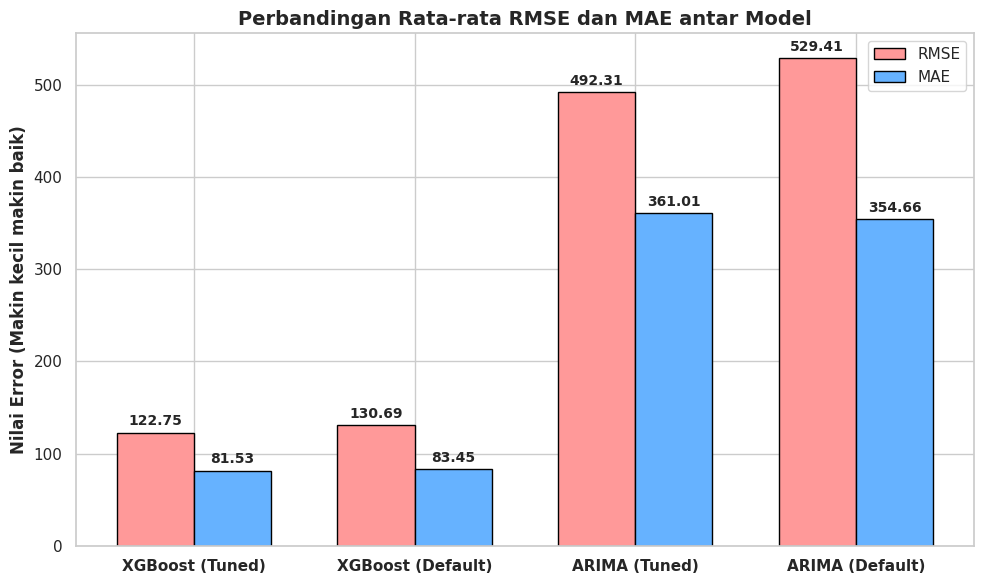

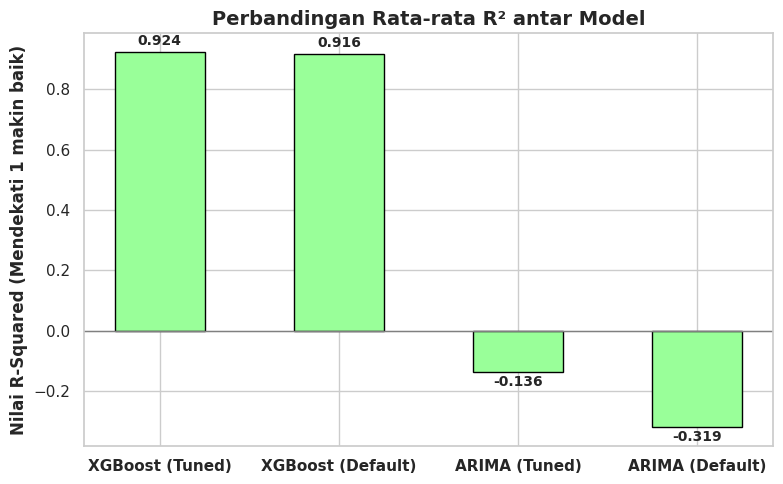

In [7]:
# =====================================================
# 7. DATA VISUALIZATION (FINAL COMPARISON)
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Menyiapkan data rata-rata dari hasil sebelumnya
avg_perf = final_results.groupby('Model')[['RMSE', 'MAE', 'R2']].mean().reset_index()

# Mengurutkan model berdasarkan RMSE (dari yang terkecil/terbaik ke yang terbesar)
avg_perf = avg_perf.sort_values(by='RMSE').reset_index(drop=True)

# Set style seaborn untuk grafik yang lebih elegan (cocok untuk skripsi)
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# GRAFIK 1: Perbandingan Metrik Error (RMSE & MAE)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(avg_perf['Model']))  # Lokasi label
width = 0.35  # Lebar bar

# Membuat bar untuk RMSE dan MAE
rects1 = ax.bar(x - width/2, avg_perf['RMSE'], width, label='RMSE', color='#FF9999', edgecolor='black')
rects2 = ax.bar(x + width/2, avg_perf['MAE'], width, label='MAE', color='#66B2FF', edgecolor='black')

# Menambahkan teks dan label
ax.set_ylabel('Nilai Error (Makin kecil makin baik)', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Rata-rata RMSE dan MAE antar Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(avg_perf['Model'], fontsize=11, fontweight='bold')
ax.legend(fontsize=11)

# Fungsi untuk menambahkan label nilai di atas bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAFIK 2: Perbandingan Metrik R-Squared (R2)
# ---------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8, 5))

# Membuat bar untuk R2
rects3 = ax2.bar(avg_perf['Model'], avg_perf['R2'], color='#99FF99', edgecolor='black', width=0.5)

# Menambahkan teks dan label
ax2.set_ylabel('Nilai R-Squared (Mendekati 1 makin baik)', fontsize=12, fontweight='bold')
ax2.set_title('Perbandingan Rata-rata R² antar Model', fontsize=14, fontweight='bold')
ax2.set_xticklabels(avg_perf['Model'], fontsize=11, fontweight='bold')

# Menambahkan garis horizontal di y=0 agar jika ada nilai minus (seperti ARIMA) terlihat jelas
ax2.axhline(0, color='gray', linewidth=1)

# Menambahkan label nilai di atas/bawah bar (karena R2 bisa negatif)
for rect in rects3:
    height = rect.get_height()
    y_pos = height + 0.02 if height >= 0 else height - 0.05
    ax2.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()